In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

In [2]:
from generic.latexify import saveimage

In [3]:
import os
import sys
# Add optimize to the path so its internal imports work
optimize_path = os.path.abspath('./optimize')
if optimize_path not in sys.path:
    sys.path.insert(0, optimize_path)

In [4]:
from visualization.settings import *
from visualization.helpers import *
from visualization.paperplots import *

In [5]:
from optimize.analyze_results import *

In [ ]:
noise_type = 'normal'  # 'gumbel' or 'normal'
# noise_type = 'gumbel'  # 'gumbel' or 'normal'
template = f'combined_outputs_20250921_fewercandidates_morevoters_{noise_type}noise'

path = 'cached_values/outputs/organized'

In [43]:
parties = ['Republican', 'Democrat']

In [44]:
df = load_organized_df(path, template, 'stv', directfromoptimization = True)

(622485, 38)
Index(['overall_hash', 'map_hash', 'settings_hash', 'state', 'state_num',
       'N_districts', 'N_VOTERS', 'total_winners', 'optimization',
       'optimization_voting_method_for', 'party_optimized_for',
       'optimization_number', 'ranking_method', 'DISTANCE_FUNCTION',
       'noise_distribution', 'noise_parameters_loc', 'noise_parameters_scale',
       'fraction_voters_Republican', 'fraction_winners_Republican', 'medians',
       'cohesion_income_Republican', 'cohesion_income_Democrat',
       'cohesion_income', 'cohesion_partisan_score_Republican',
       'cohesion_partisan_score_Democrat', 'cohesion_partisan_score',
       'cohesion_education_Republican', 'cohesion_education_Democrat',
       'cohesion_education', 'cohesion_racial_Republican',
       'cohesion_racial_Democrat', 'cohesion_racial',
       'cohesion_geographic_Republican', 'cohesion_geographic_Democrat',
       'cohesion_geographic', 'winner_location_variance',
       'winner_location_variance_Democrat

In [45]:
df.shape

(622528, 44)

In [46]:
df = df.dropna(subset = ['optimization_number'])
df.shape

(622485, 44)

In [47]:
df['fraction_voters_Republican'] = df['fraction_voters_Republican_x']

In [48]:
df.columns

Index(['overall_hash', 'map_hash', 'settings_hash', 'state', 'state_num',
       'N_districts', 'N_VOTERS', 'total_winners', 'optimization',
       'optimization_voting_method_for', 'party_optimized_for',
       'optimization_number', 'ranking_method', 'DISTANCE_FUNCTION',
       'noise_distribution', 'noise_parameters_loc', 'noise_parameters_scale',
       'fraction_voters_Republican_x', 'fraction_winners_Republican',
       'medians', 'cohesion_income_Republican', 'cohesion_income_Democrat',
       'cohesion_income', 'cohesion_partisan_score_Republican',
       'cohesion_partisan_score_Democrat', 'cohesion_partisan_score',
       'cohesion_education_Republican', 'cohesion_education_Democrat',
       'cohesion_education', 'cohesion_racial_Republican',
       'cohesion_racial_Democrat', 'cohesion_racial',
       'cohesion_geographic_Republican', 'cohesion_geographic_Democrat',
       'cohesion_geographic', 'winner_location_variance',
       'winner_location_variance_Democrat',
       '

In [49]:
cols_areunique = ['map_hash', 'noise_parameters_scale', 'optimization','optimization_number','party_optimized_for']
df.shape, df.drop_duplicates().shape, df.drop_duplicates(subset=cols_areunique).shape, df.overall_hash.nunique()

((622485, 44), (622485, 44), (622485, 44), 487791)

noise_parameters_scale
0.0        0.008730
5.0        0.008858
10.0       0.009585
50.0       0.013351
100.0      0.015395
250.0      0.019361
500.0      0.023222
1000.0     0.025366
25000.0    0.026789
50000.0    0.026379
Name: fraction_winners_Republican, dtype: float64

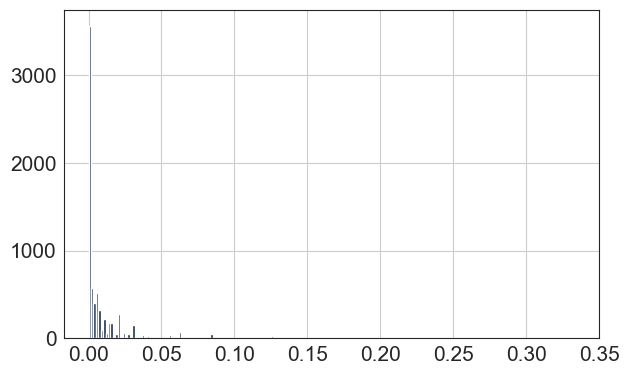

In [ ]:

df_dupes = df[df.duplicated(subset=['map_hash', 'noise_parameters_scale'], keep=False)]
df_dupes_sorted = df_dupes.sort_values(by=['map_hash', 'noise_parameters_scale', 'optimization_number'])
df_dupes_sorted[['map_hash', 'noise_parameters_scale', 'optimization', 'optimization_number', 'party_optimized_for','total_winners', 'fraction_winners_Republican']].query('noise_parameters_scale==0')

df_dupes_sorted[['map_hash', 'noise_parameters_scale', 'optimization', 'optimization_number', 'party_optimized_for','total_winners', 'fraction_winners_Republican']].query('noise_parameters_scale==0').groupby(['map_hash', 'noise_parameters_scale'])['fraction_winners_Republican'].var().hist(bins = 200)

df_dupes_sorted[['map_hash', 'noise_parameters_scale', 'optimization', 'optimization_number', 'party_optimized_for','total_winners', 'fraction_winners_Republican']].groupby(['map_hash', 'noise_parameters_scale'])['fraction_winners_Republican'].var().reset_index().groupby('noise_parameters_scale')['fraction_winners_Republican'].mean()

In [51]:
cols_to_drop_duplicates = ['overall_hash','settings_hash','map_hash', 'noise_parameters_scale', 'noise_distribution']
df.drop_duplicates(subset=cols_to_drop_duplicates).shape, df.overall_hash.nunique()
# cols_to_create_hash_for_matching = ['map_hash']

((487791, 44), 487791)

In [52]:
for col in df.columns:
    print(col, df[col].nunique())

overall_hash 487791
map_hash 93969
settings_hash 10
state 42
state_num 42
N_districts 30
N_VOTERS 1
total_winners 18
optimization 4
optimization_voting_method_for 1
party_optimized_for 2
optimization_number 102
ranking_method 1
DISTANCE_FUNCTION 1
noise_distribution 1
noise_parameters_loc 1
noise_parameters_scale 10
fraction_voters_Republican_x 112
fraction_winners_Republican 134
medians 620867
cohesion_income_Republican 613603
cohesion_income_Democrat 607472
cohesion_income 621778
cohesion_partisan_score_Republican 613623
cohesion_partisan_score_Democrat 607478
cohesion_partisan_score 621778
cohesion_education_Republican 613620
cohesion_education_Democrat 607476
cohesion_education 621777
cohesion_racial_Republican 613600
cohesion_racial_Democrat 607460
cohesion_racial 621765
cohesion_geographic_Republican 613625
cohesion_geographic_Democrat 607476
cohesion_geographic 621779
winner_location_variance 621396
winner_location_variance_Democrat 570376
winner_location_variance_Republican 590

In [53]:
hash_column_to_drop = 'overall_hash'
dfdedup = df.copy()
#shuffle before dropping duplicates to avoid any bias
dfdedup = dfdedup.sample(frac=1, random_state=42).reset_index(drop=True)

In [54]:
dfdedup = dfdedup.drop_duplicates(subset = [hash_column_to_drop])
dfdedup.shape

(487791, 44)

In [55]:
dforig = df.copy()
df = dfdedup

# analysis after dealing with hashes

In [56]:
hash_column_for_matching = 'map_hash'

In [57]:
df.columns

Index(['overall_hash', 'map_hash', 'settings_hash', 'state', 'state_num',
       'N_districts', 'N_VOTERS', 'total_winners', 'optimization',
       'optimization_voting_method_for', 'party_optimized_for',
       'optimization_number', 'ranking_method', 'DISTANCE_FUNCTION',
       'noise_distribution', 'noise_parameters_loc', 'noise_parameters_scale',
       'fraction_voters_Republican_x', 'fraction_winners_Republican',
       'medians', 'cohesion_income_Republican', 'cohesion_income_Democrat',
       'cohesion_income', 'cohesion_partisan_score_Republican',
       'cohesion_partisan_score_Democrat', 'cohesion_partisan_score',
       'cohesion_education_Republican', 'cohesion_education_Democrat',
       'cohesion_education', 'cohesion_racial_Republican',
       'cohesion_racial_Democrat', 'cohesion_racial',
       'cohesion_geographic_Republican', 'cohesion_geographic_Democrat',
       'cohesion_geographic', 'winner_location_variance',
       'winner_location_variance_Democrat',
       '

In [58]:
df.optimization_voting_method_for.unique()

array(['thiele_pav', nan], dtype=object)

In [59]:
df.party_optimized_for.unique()

array(['r_opt_solutions', 'd_opt_solutions', nan], dtype=object)

In [60]:
df.loc[:, 'N_winners_Republican'] = df.eval('fraction_winners_Republican * total_winners').round().astype(int)

In [61]:
df.noise_parameters_scale.value_counts()

noise_parameters_scale
5.0        93969
100.0      48637
50.0       48637
250.0      48637
500.0      48637
1000.0     48637
25000.0    48637
50000.0    48637
0.0        48637
10.0        4726
Name: count, dtype: int64

# Proportionality stuff

In [62]:
df.head()

,overall_hash,map_hash,settings_hash,state,state_num,N_districts,N_VOTERS,total_winners,optimization,optimization_voting_method_for,...,cohesion_geographic,winner_location_variance,winner_location_variance_Democrat,winner_location_variance_Republican,fraction_voters_Republican_y,N_winners_Republican,district_vote_shares,district_n_winners,fraction_voters_Republican,district_n_winners_Republican
0,17b0b74f86416855e817972600d3c4722cf2369ae0ca23...,2cf2369ae0ca23dc997403a1a127ebf9,17b0b74f86416855e817972600d3c472,NY,36.0,10,50000.0,27.0,unfair,thiele_pav,...,-31593.030670,137837.526478,120636.350944,201953.236650,0.365521,4.0,NaN,NaN,0.366460,NaN
1,8dc48caaded9c29ea26cb9a6f0fb084081fa1ad711b87b...,81fa1ad711b87b8433f853a4bf51bd92,8dc48caaded9c29ea26cb9a6f0fb0840,FL,12.0,3,50000.0,27.0,unfair,thiele_pav,...,-102317.852963,191188.367955,186897.930808,188421.111503,0.508415,14.0,NaN,NaN,0.507360,NaN
2,8dc48caaded9c29ea26cb9a6f0fb0840cff4dc88f08ca9...,cff4dc88f08ca9e4eefb637d6543c7e4,8dc48caaded9c29ea26cb9a6f0fb0840,MO,29.0,2,50000.0,8.0,unfair,thiele_pav,...,-134280.514717,153399.435802,100361.155318,164762.068695,0.546596,4.0,NaN,NaN,0.554869,NaN
3,b17ce6499c8464157773480894a5e79114c0b54d53a894...,14c0b54d53a8944f2e3c0e8ac5b8ba87,b17ce6499c8464157773480894a5e791,NY,36.0,8,50000.0,27.0,fair,thiele_pav,...,-36292.804665,149076.644010,117821.414534,218262.816250,0.365521,5.0,NaN,NaN,0.366640,NaN
4,27d0650d11a8fe125045b09929e6af9f21e6bd6cc65417...,21e6bd6cc6541791ea6f5ffa44af79b6,27d0650d11a8fe125045b09929e6af9f,IL,17.0,10,50000.0,18.0,unfair,thiele_pav,...,-40152.800969,126107.983697,113072.945699,138551.505254,0.403243,9.0,NaN,NaN,0.402680,NaN


In [63]:
distribution_0noise, distribution_0noise_indices = state_seat_share_distributions_nikhil_with_hashes(
    df.query(f'noise_parameters_scale == {0}'), hash_col = hash_column_for_matching
)
distribution_0noise_indices['TX'].head()

['IL' 'MO' 'OH' 'TX' 'FL' 'CA' 'NC' 'TN' 'NY' 'WA' 'IN' 'MN' 'SC' 'AL'
 'MD' 'PA' 'VA' 'MA' 'IA' 'WI' 'CT' 'NV' 'CO' 'NE' 'AZ' 'NJ' 'HI' 'NM'
 'OK' 'GA' 'MI' 'UT' 'RI' 'AR' 'MS' 'ID' 'LA' 'ME' 'OR' 'KS' 'KY' 'NH']
don't have state, skipping:  WV


,1,2,3,4,5,6,7,8,9,10,...,14,16,18,20,23,26,29,32,35,36
Most Republican,[c8cb56cc09d7f5b799811a4f32bdcf29],"[58caa591d8a0203d30b7ef67e25da4a9, 4f50189f31e...","[960b1ebd937feca674417c191a6196d0, 1657ed80e81...","[00e5402634c4901330c0fd05c7380363, 2fe3f2d886c...","[4914e17b7103d2c97a8e597b0cca3554, 95d1d2ca4ba...","[6e6dc8877f54ce62bf1f205e9a466fb8, 2bf92f2caef...","[46f471621b64774f52ea60879e846d06, 4009daa81e0...","[124223c31b8b2df728c3542e112750c0, 68125caf814...","[afdccf645156226e4c06f9ccbd7dce0f, 5f5a7500647...","[3dc8140e5928b209ab2441a286bd5a3f, 05877ed6f50...",...,"[2f3f31eaa46a57ecb2674266b122b4f5, 47c15cb8539...","[1c5dddaabd2321ef979255992a3f678d, 2b6da61eeb0...","[995ca6d23d737b21f6e6bed8534925b2, b9fccb432f7...","[bec862d4f4a816b566b359188173039e, 3fb5ec6b6ef...","[b692d650aefa0b18ca39ce3300a6eddc, dbec42b6c24...","[4a6794c1c2914e17b35e9ff2bcc3abc0, 12fde0cc2c7...","[b8e2e7e0e635d78e5e34121516e04420, e91639b08a4...","[5a0f7421383b4793a715006473c3dac3, d40637eeeea...","[ccb83c660b0fdd6aad5de45c25ca8a52, a4e8aecd094...","[52757e4edaecc1da9c239674219f4a6b, 6420bf15dfc..."
Median,[c8cb56cc09d7f5b799811a4f32bdcf29],"[f90495c42cce0728e269c2f99f7fbb80, 926d7f8978b...","[da6d4036148f5ca40437f30ad005b01d, a604ef330ba...","[98f43eae2a9436a08a69df72f8d84188, e225b7ee1d3...","[83d0ad63ee7a5663e69b593c7a814a0c, afb188aa939...","[ea5d6c91ea663db8f2cc525a69ec6c8b, 41cb3d5dbe4...","[355339db4b43d792f1a6e528df97112f, b470a11e2df...","[657f59192413c6736fec93f662803393, 60d8be6ef95...","[eb1902a394371d683669383bc9a4a84a, e35278315de...","[1d25b5217c93d91573ebe6f4acc7ac6e, 4ef3ebf97ca...",...,"[7a4d2849a8cae74a08878a99a64e7772, 5eadf9ef2b3...","[a4ca12aaafc7342dad4b69f7a9ba1b12, 84cd9d5a3d8...","[314e6309efec80bed46c8d825eaa6bfd, 5676cebc1c0...","[25975f8e488d4d681f2ebafbc6a8ab12, 7f4d2d470a5...","[5f24c379cd86946c19f8eed149abf78f, e12842b97e5...","[ff33a263fe5a1881f6d2d605ee5e31a3, af2e521c671...","[41ac2f53bb39ab0aba511792f38c07d3, 69bdd4b1ef6...","[80b16218128ad68fa086a3a225c50cbb, 6004e257eff...","[ef047ab22cf436bfc4bc59955c7ab029, 75e5addaf3a...","[2353cb4f757a77729c48ad3179fc70b2, 639198d4627..."
Most Fair in each state,[c8cb56cc09d7f5b799811a4f32bdcf29],"[4cfdbd2e3123691e2039e3ae32fb264e, 80930703825...","[c3246f9c333a95c7c84034c5bf722635, 36ef9c5564e...","[98f43eae2a9436a08a69df72f8d84188, 64b098218bc...","[83d0ad63ee7a5663e69b593c7a814a0c, 7197cf5920b...","[81a1f444975e79e0962c3091cdc0c5a3, 8f11efb28f1...","[b5f649c066a9f6366990b66d98f17433, 19626f6efde...","[bf0d4f5467d440627b692387a6087803, e118099f0a5...","[b09f30c7218a5d8a666627cba871a989, d52246abd23...","[b61e5309e7496e62854275d0cd67025f, 467ab20df64...",...,"[5ca41a39431969325a7469a63f2068a9, 1dd251e704c...","[ff5fc37fcd0c3b6f1e4b16f026f9ed42, 76bf1e82562...","[86e2a9737b3b9fcb84e17fe996428613, 74d438724c7...","[27da64cae6552340f57c436f718cf5e4, 4f2f2cf9c23...","[753952fc01ad6945b7268ee94858a703, faaf989067a...","[56dc28aea95659c043c731a5a50ebc19, 0c0d24a71e4...","[33635de9069ab7f2171d75c3f0fb15be, cddf1bd5cbc...","[a617f0c1b76ec84853aa554a88885988, da9f50e1474...","[cbf1c4f595f07b570045387b643e404d, 02005111751...","[5ebff66026fc78be95b107e39a962da4, 98d652e5685..."
Most Democratic,[c8cb56cc09d7f5b799811a4f32bdcf29],"[4cfdbd2e3123691e2039e3ae32fb264e, 80930703825...","[a1562dcd9221ff77b01cfd0e89fcd946, d055059b72a...","[64b098218bc33ffdd3c0a16e2a52b6c9, 1f2b7ddda1b...","[f008ff1ed16fa3db8c55ade2be82a94e, 57290a20f4d...","[6dc62c90a6872500e774c9ccae8764e4, e8830435a2c...","[23c3880d91d0bd4ff4d7fae8fb1a7c70, ffe2e653bcb...","[e118099f0a581dcdfc10c8c3a9bd7222, 6fedd440b28...","[d52246abd23db85ba4aabd42e338d7fc, 71d717afcea...","[68462734d977718a61987ebab2e2c222, fb8539d4d9f...",...,"[5ca41a39431969325a7469a63f2068a9, c79b0cb1f47...","[ff5fc37fcd0c3b6f1e4b16f026f9ed42, 76bf1e82562...","[86e2a9737b3b9fcb84e17fe996428613, 66dfcbe66e9...","[4f2f2cf9c23231b96f22af7053a4a4cc, 87ec063869d...","[7aebf11f732ff4f81f03cad2188f4c49, d7cd838d50f...","[7d3af202a523ed3cc9adefaab1a9320

In [64]:
distribution_0noise['TX'].head()

,1,2,3,4,5,6,7,8,9,10,...,14,16,18,20,23,26,29,32,35,36
Most Republican,0.555556,0.611111,0.611111,0.611111,0.622863,0.615741,0.626984,0.640625,0.647661,0.651910,...,0.677778,0.683761,0.688406,0.710317,0.708333,0.732456,0.752137,0.744949,0.761696,0.758681
Median,0.555556,0.583333,0.583333,0.583333,0.583333,0.611111,0.611111,0.611111,0.611111,0.611111,...,0.638889,0.638889,0.638889,0.638889,0.666667,0.638889,0.638889,0.611111,0.666667,0.638889
Most Fair in each state,0.555556,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,...,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333
Most Democratic,0.555556,0.579630,0.578431,0.575163,0.578125,0.573718,0.570175,0.569444,0.575163,0.577381,...,0.569444,0.572222,0.567901,0.569923,0.545833,0.545139,0.550000,0.538889,0.542735,0.539683


In [65]:
distributions_0noise_fromindices = distributions_from_hash_means(
    df.query(f'noise_parameters_scale == {0}'),
    distribution_0noise_indices
    , hash_col = hash_column_for_matching
)
distributions_0noise_fromindices['TX'].head()

,1,2,3,4,5,6,7,8,9,10,...,14,16,18,20,23,26,29,32,35,36
Most Republican,0.555556,0.611111,0.611111,0.611111,0.622863,0.615741,0.626984,0.640625,0.647661,0.651910,...,0.677778,0.683761,0.688406,0.710317,0.708333,0.732456,0.752137,0.744949,0.761696,0.758681
Median,0.555556,0.583333,0.583333,0.583333,0.583333,0.611111,0.611111,0.611111,0.611111,0.611111,...,0.638889,0.638889,0.638889,0.638889,0.666667,0.638889,0.638889,0.611111,0.666667,0.638889
Most Fair in each state,0.555556,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,...,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333
Most Democratic,0.555556,0.579630,0.578431,0.575163,0.578125,0.573718,0.570175,0.569444,0.575163,0.577381,...,0.569444,0.572222,0.567901,0.569923,0.545833,0.545139,0.550000,0.538889,0.542735,0.539683


In [66]:
# confirm that distributions_0noise_fromindices, distribution_0noise are the same; they should be!
for state in distribution_0noise.keys():
    assert np.allclose(
        distribution_0noise[state],
        distributions_0noise_fromindices[state]
    )

In [67]:
distributions = {noise_scale 
                 : distributions_from_hash_means(
                     df.query(f'noise_parameters_scale == {noise_scale}')
                     , distribution_0noise_indices
                     , hash_col = hash_column_for_matching
                     ) for noise_scale in df.noise_parameters_scale.unique()}

distributions_maximizeexpost = {}
for noise_scale in df.noise_parameters_scale.unique():
    distributions_maximizeexpost[noise_scale], _ = state_seat_share_distributions_nikhil_with_hashes(
        df.query(f'noise_parameters_scale == {noise_scale}'), hash_col = hash_column_for_matching
)

['NY' 'CA' 'VA' 'RI' 'TX' 'MN' 'NC' 'FL' 'NJ' 'MA' 'IL' 'CT' 'WA' 'MI'
 'TN' 'NE' 'MD' 'SC' 'AZ' 'OH' 'AR' 'PA' 'WI' 'MO' 'KY' 'AL' 'OR' 'GA'
 'IN' 'NM' 'IA' 'CO' 'MS' 'ME' 'UT' 'LA' 'KS' 'OK' 'NV' 'ID' 'HI' 'NH']
don't have state, skipping:  WV
['FL' 'MO' 'TX' 'NY' 'MD' 'GA' 'VA' 'IL' 'IN' 'AR' 'OR' 'OH' 'MN' 'WA'
 'CA' 'TN' 'PA' 'NC' 'AL' 'CO' 'ME' 'NJ' 'CT' 'AZ' 'MI' 'WI' 'KY' 'NE'
 'MA' 'HI' 'UT' 'NV' 'SC' 'LA' 'ID' 'OK' 'KS' 'RI' 'MS' 'NM' 'IA' 'NH']
don't have state, skipping:  WV
['NY' 'MA' 'CA' 'GA' 'AZ' 'CO' 'OK' 'MI' 'TX' 'IA' 'PA' 'IL' 'SC' 'NC'
 'WA' 'KY' 'OH' 'NM' 'FL' 'MN' 'NJ' 'MS' 'KS' 'MO' 'IN' 'VA' 'AL' 'NH'
 'HI' 'UT' 'CT' 'MD' 'ME' 'NV' 'TN' 'OR' 'WI' 'LA' 'AR' 'RI' 'NE' 'ID']
don't have state, skipping:  WV
['IL' 'NJ' 'FL' 'NY' 'TX' 'PA' 'OH' 'SC' 'WA' 'OR' 'MD' 'NH' 'GA' 'KY'
 'MI' 'MN' 'IN' 'MA' 'TN' 'NM' 'AZ' 'LA' 'AL' 'WI' 'KS' 'VA' 'NC' 'CA'
 'CT' 'MO' 'NV' 'AR' 'NE' 'MS' 'ME' 'IA' 'CO' 'OK' 'ID' 'RI' 'UT' 'HI']
don't have state, skipping:  WV
['OR' 'NJ' 'GA' 

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# I would expect at 0 noise and 1 district, to be very proportional
distributions[0]['TX']

,1,2,3,4,5,6,7,8,9,10,...,14,16,18,20,23,26,29,32,35,36
Most Republican,0.583333,0.611111,0.611111,0.614379,0.617593,0.620635,0.643939,0.649758,0.648889,0.670940,...,0.677579,0.708333,0.709402,0.726496,0.733660,0.743056,0.762222,0.760870,0.765432,0.783730
Median,0.583333,0.583333,0.583333,0.611111,0.611111,0.611111,0.611111,0.611111,0.611111,0.611111,...,0.638889,0.638889,0.666667,0.638889,0.666667,0.666667,0.638889,0.638889,0.694444,0.638889
Most Fair in each state,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,...,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333
Most Democratic,0.583333,0.578704,0.572917,0.565476,0.578947,0.578125,0.569444,0.572650,0.599617,0.603943,...,0.571637,0.566358,0.559028,0.549145,0.540598,0.565972,0.543210,0.539216,0.543403,0.545139


In [ ]:
# I would expect at 50000 noise and at every district size, to be very proportional
distributions[50000]['TX']

,1,2,3,4,5,6,7,8,9,10,...,14,16,18,20,23,26,29,32,35,36
Most Republican,0.527778,0.500000,0.509259,0.483660,0.511111,0.507937,0.513889,0.496377,0.485556,0.491453,...,0.497024,0.503968,0.494658,0.521368,0.500000,0.489583,0.508889,0.472222,0.503086,0.523810
Median,0.527778,0.521605,0.504167,0.510234,0.489766,0.481838,0.505556,0.516082,0.508170,0.506173,...,0.506614,0.526316,0.501736,0.504902,0.500000,0.478395,0.493056,0.462302,0.487654,0.522876
Most Fair in each state,0.527778,0.517361,0.495773,0.502058,0.505000,0.500000,0.511905,0.491358,0.498413,0.481481,...,0.517778,0.502924,0.498148,0.496732,0.508102,0.525132,0.486928,0.474474,0.500000,0.519231
Most Democratic,0.527778,0.509259,0.475694,0.505952,0.502924,0.510417,0.509921,0.504274,0.514368,0.500000,...,0.517544,0.490741,0.494792,0.497863,0.497863,0.497685,0.475309,0.473856,0.500000,0.475694


In [ ]:
noise_vals = sorted(distributions.keys())
noise_vals

[np.float64(0.0),
 np.float64(5.0),
 np.float64(10.0),
 np.float64(50.0),
 np.float64(100.0),
 np.float64(250.0),
 np.float64(500.0),
 np.float64(1000.0),
 np.float64(25000.0),
 np.float64(50000.0)]

In [ ]:
dfloc = df.query('noise_parameters_scale == 0')
dfff = (
    dfloc.groupby("state")[["total_winners", "fraction_voters_Republican"]]
    .mean()
    .reset_index()
)
proportionality = (
    dfff.eval("total_winners*fraction_voters_Republican").sum()
    / dfff["total_winners"].sum()
)

In [ ]:
noise_vals_todo = noise_vals.copy()
noise_vals_todo = [
np.float64(0.0),
 np.float64(5.0),
#  np.float64(10.0),
 np.float64(50.0),
 np.float64(100.0),
 np.float64(250.0),
 np.float64(500.0),
#  np.float64(1000.0),
#  np.float64(25000.0),
#  np.float64(50000.0)
 ]

0.0
5.0
50.0
100.0
250.0
500.0


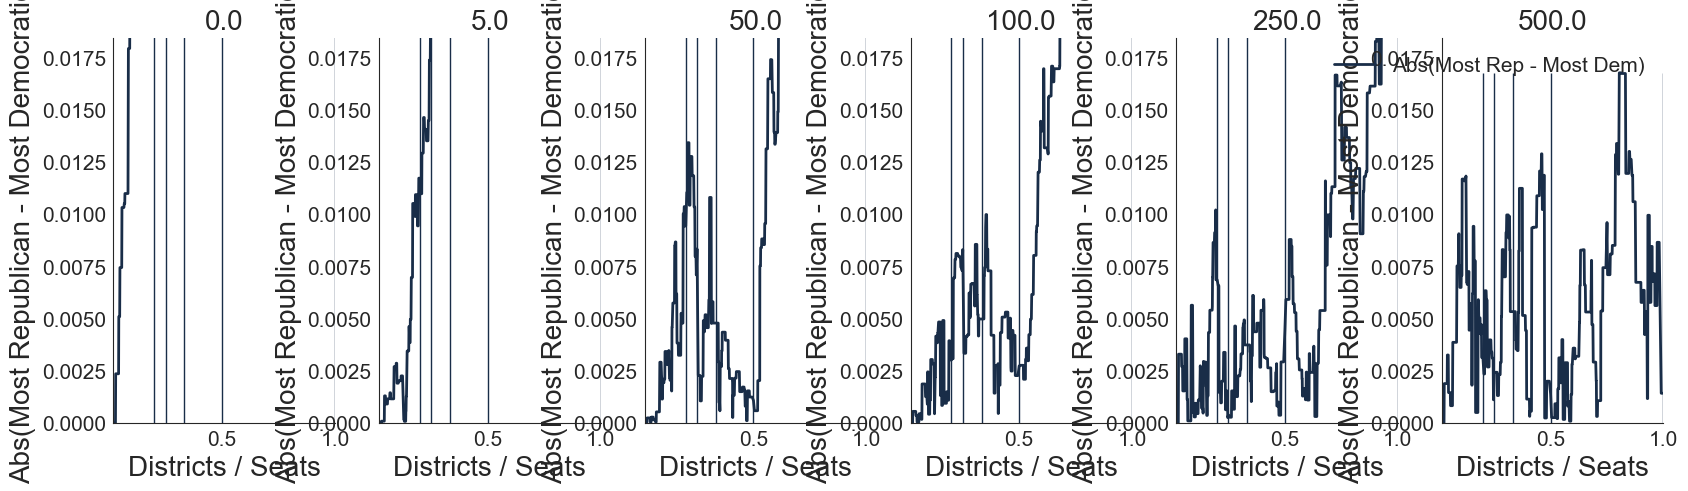

In [ ]:
# 1/2/2026 to plot the difference between most rep and most dem across all states
ax1 = None
fig = plt.figure(figsize = (20, 5))
for enn, method in enumerate(noise_vals_todo):
    if enn == 0:
        ax = plt.subplot(int('1{}{}'.format(len(noise_vals_todo), enn+1)))
        ax1 = ax
    else:
        ax = plt.subplot(int('1{}{}'.format(len(noise_vals_todo), enn+1)), sharey = ax1)
    print(method)
    _ = plot_all_state_rep_dem_gap(distributions[method]
                                                        #  , prop_val = get_prop(df.query(f'noise_parameters_scale == {method}'))
                                                         , do_vertical_integers = True, legend = enn==len(noise_vals_todo)-1
                                            , ax = ax
                                            # , party_colors = True
                                            # , bbox_to_anchor=(-7, 1.055)
                                            # , legendncol = 4, legendfontsize = 20
                                            )
    ax.set_title(method, fontsize = 20)
# saveimage('prop_differentnoise', extension = 'pdf')

Noise level 0.0, gap min 0.0, max 0.2628194141747556
Noise level 5.0, gap min 0.0, max 0.1250910165901029
Noise level 50.0, gap min 0.0, max 0.07320755059563379
Noise level 100.0, gap min 0.0, max 0.051179666473979334
Noise level 250.0, gap min 0.0, max 0.028530331626320397
Noise level 500.0, gap min 0.0, max 0.016797935550970953
ymin, ymax:  0.0 0.2628194141747556


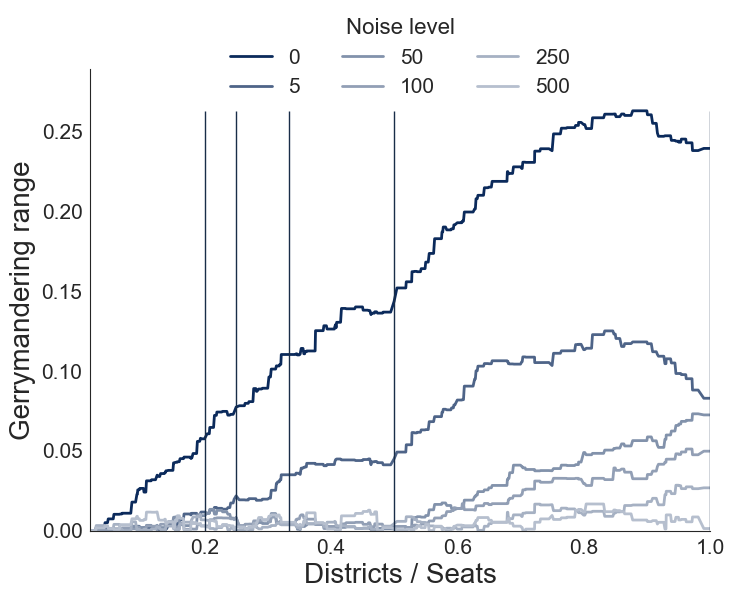

In [ ]:
# 1/2/2026 to plot the difference between most rep and most dem across all states in one plot
fig = plot_all_state_rep_dem_gap_by_noise({k:distributions[k] for k in noise_vals_todo}
                                            #  , prop_val = get_prop(df.query(f'noise_parameters_scale == {method}'))
                                            , do_vertical_integers = True, legend = enn==len(noise_vals_todo)-1
                                            # , ax = ax
                                            # , party_colors = True
                                            # , bbox_to_anchor=(-7, 1.055)
                                            , legendncol = 3,
                                            # legendfontsize = 20
                                            )
# ax.set_title(method, fontsize = 20)
# plt.show()
saveimage('gerrymanderinggap_by_noise_morevoters_20250921_{}'.format(noise_type), extension = 'pdf', close = False)
plt.show()